## Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from numpy.linalg import LinAlgError


from sklearn.metrics import mean_squared_error as mse

from statsmodels.tsa.seasonal import seasonal_decompose as sd
from statsmodels.tsa.stattools import adfuller as adf
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

from datetime import datetime

from prophet import Prophet
from math import sqrt

import plotly.graph_objs as go
import plotly.offline as py

## Load Data Set

In [2]:
data = pd.read_csv(r"E:\DATA FOR TEST\AirPassengers.csv")
df = data.copy()
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

## 1

#### Remove Unnessary Coloumns

#### Features Date Time Conversion And Diffrence Feature Created

In [3]:
# # Features Date Time Conversion
# df['Month'] = pd.to_datetime(df.Month)
# df.set_index('Month', inplace=True)

#### Find And Fill Missing Values

In [4]:
# Find Missing Values
print('Total Missing Values :\n', df.isna().sum())

Total Missing Values :
 #Passengers    0
dtype: int64


#### Handle Outliers

In [5]:
def find_outliers(df):
    
    outliers = []
    
    mean = df.mean()
    std = df.std()

    lower_limit = mean - std * 3
    upper_limit = mean + std * 3

    for values in df:
        if values > upper_limit or values < lower_limit:
            outliers.append(values)
    return outliers

In [6]:
# Find Outliers of TotalSpend 
print('Before : ', find_outliers(df['#Passengers']), 'Length : ', len(find_outliers(df['#Passengers'])))

Before :  [] Length :  0


### ADF TEST

#### Peform Test ON # Passangers

In [7]:
Names = ['ADF Statistical Number', 'P-Value', 'Used Lags', 'No of Observation', 'Critical Values', 'AIC']

result = adf(df['#Passengers'])

for name, value in zip(Names, result):
    print(f"{name} : {value}")

ADF Statistical Number : 0.8153688792060482
P-Value : 0.991880243437641
Used Lags : 13
No of Observation : 130
Critical Values : {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC : 996.692930839019


#### Peform Test ON Months

In [8]:
# Names = ['ADF Statistical Number', 'P-Value', 'Used Lags', 'No of Observation', 'Critical Values', 'AIC']

# result = adf(df['Month']) 
# for name, value in zip(Names, result):
#     print(f"{name} : {value}")

#### Perform Seasonality on Raw Data 

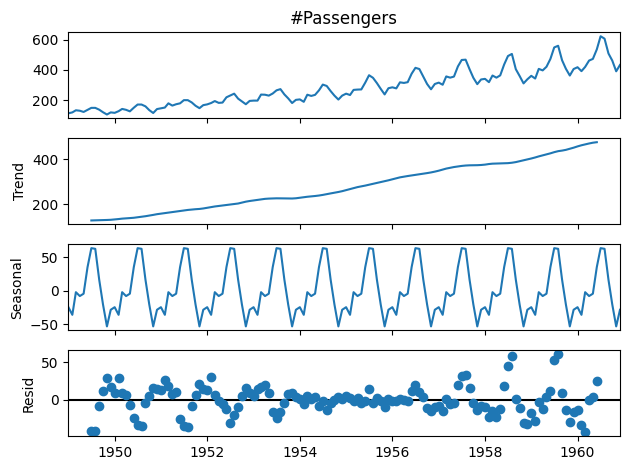

In [9]:
Results = sd(df['#Passengers'], model='Multiplicative')
Results.plot()
plt.show();

#### Resid and Seasonal are Moving in Very High Range 0 To 50

In [10]:
#### Perform Log Transformation on # Passangers Data
df['log_#Passengers'] = np.log(df['#Passengers'])


#### Perform Seasonality on Logarithmic Data

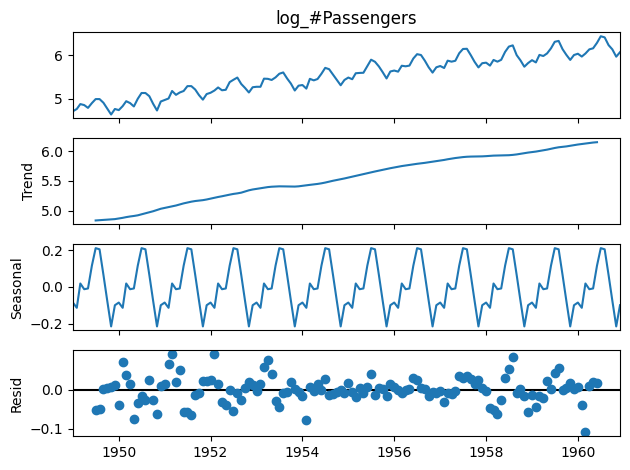

In [11]:
log_results = sd(df['log_#Passengers'])
log_results.plot()
plt.show()

In [12]:
# Check Skewness of Data
print('Skewness of Following :\n')
print(f'#Passengers\t : {df['#Passengers'].skew()}')
print(f'log_#Passengers  : {df['log_#Passengers'].skew()}')

Skewness of Following :

#Passengers	 : 0.5831604861560892
log_#Passengers  : -0.12200106485974971


#### Kernal Density Estimator Plot

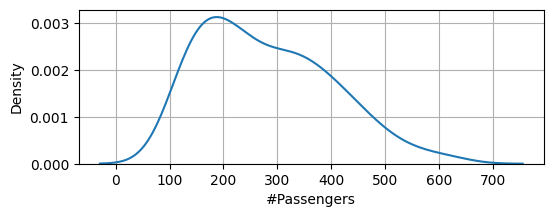

In [17]:
plt.figure(figsize=(6, 2))
sns.kdeplot(df['#Passengers'])
plt.grid()


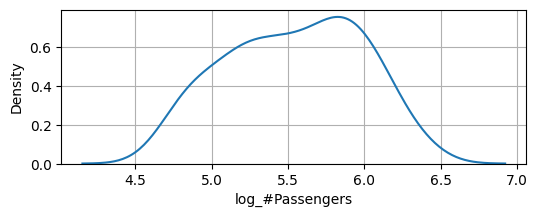

In [18]:
plt.figure(figsize=(6, 2))
sns.kdeplot(df['log_#Passengers'])
plt.grid()


## 2

#### Data Preview

In [19]:
# Top 5 Data
df.head()

,#Passengers,log_#Passengers
Month,,
1949-01-01,112,4.718499
1949-02-01,118,4.770685
1949-03-01,132,4.882802
1949-04-01,129,4.859812
1949-05-01,121,4.795791


In [20]:
# Bottom 5 Data
df.tail()

,#Passengers,log_#Passengers
Month,,
1960-08-01,606,6.406880
1960-09-01,508,6.230481
1960-10-01,461,6.133398
1960-11-01,390,5.966147
1960-12-01,432,6.068426


In [21]:
# Data Information
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   #Passengers      144 non-null    int64  
 1   log_#Passengers  144 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 3.4 KB


#### Data Paring in DateTime For DateTime Convestion

In [22]:
# The data contains a particular month and number of passengers travelling in that month.
# In order to read the data as a time series, we have to pass special arguments to the

data = pd.read_csv(r"E:\DATA FOR TEST\AirPassengers.csv",
                   parse_dates=['Month'],
                   index_col='Month',
                   date_format='%Y-%m'  # %m as no(1,2,..,12), %b as name(jan, feb..,dec)
)

# Creating Time Series Data
ts = data['#Passengers']
ts.tail()

Month
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: #Passengers, dtype: int64

#### Indexing Time Series Array (find Passenger by Index by Month)

In [23]:
print('1949-03-01 :\t', ts['1949-03-01'])
print('1959-03-01 :\t', ts['1959-03-01'])


# Only March Data on All Years
march_data = ts[ts.index.month == 3]
print(march_data)

1949-03-01 :	 132
1959-03-01 :	 406
Month
1949-03-01    132
1950-03-01    141
1951-03-01    178
1952-03-01    193
1953-03-01    236
1954-03-01    235
1955-03-01    267
1956-03-01    317
1957-03-01    356
1958-03-01    362
1959-03-01    406
1960-03-01    419
Name: #Passengers, dtype: int64


In [24]:
# By Library of datetime
ts[datetime(1959, 3, 1)] # No Zero ALlowed

406

#### Check Stationary

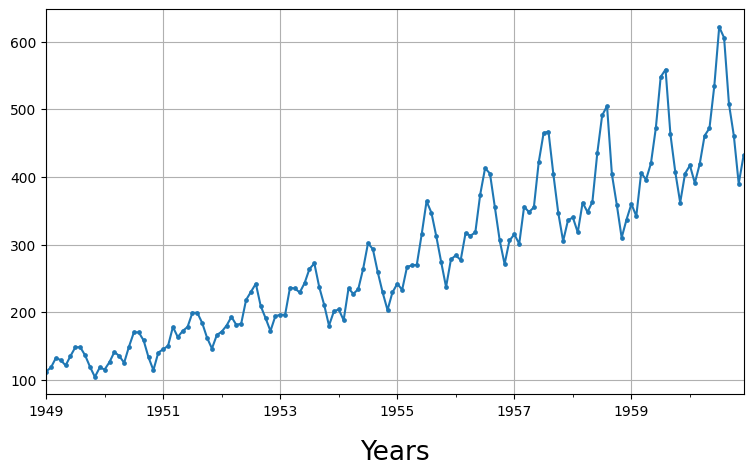

In [25]:
# By Visulization
plt.figure(figsize=(9, 5))
ts.plot(marker='o', markersize=2.4)
plt.grid()
plt.yticks([x for x in np.linspace(100, 600, 6)])
plt.xlabel('Years', labelpad=15, fontsize=19)
plt.show()

####  Stationary Test(adf) on Raw Data

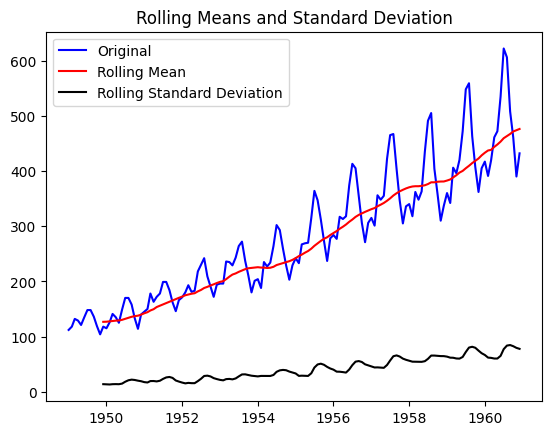

ADF Statistical Number 0.8153688792060482
P-Value 0.991880243437641
Used Lags 13
No of Observation 130
Critical Values {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC 996.692930839019


In [26]:
# Create Function To Find adf Test

# H0 = Data is Not Stationary
# H1 = Data is Stationary

def test_stationary(timeseries):

    # Determin Rolling Statistics

    roll_mean = pd.Series(timeseries).rolling(window=12).mean()
    roll_std = pd.Series(timeseries).rolling(window=12).std()

    # Plot Rolling Statistics
    orig = plt.plot(timeseries, color='Blue', label='Original')
    mean = plt.plot(roll_mean, color='Red', label='Rolling Mean')
    std = plt.plot(roll_std, color='Black', label='Rolling Standard Deviation')
    plt.legend(loc='best')
    plt.title('Rolling Means and Standard Deviation')
    plt.show(block=False)

    # Perform Duckky Fuller Test
    Names = ['ADF Statistical Number', 'P-Value', 'Used Lags', 'No of Observation', 'Critical Values', 'AIC']
    result = adf(timeseries, autolag='AIC')
    for Name, Value in zip(Names, result):
        print(Name, Value)


test_stationary(ts)

####  Making Time Series Data Stationary

###### Log Transformation
###### Double Log Transformation
###### Smoothing Techniqes ---> Log + MovingAverage + Diffrenceing
###### Diffrenceing
###### Double Diffrencing
###### Log Diffrencing

##### After  Forcasting is Done, ALways to inverase Transformation

In [27]:
# Time Seriest Top Values
ts.head()

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: #Passengers, dtype: int64

####  Log Transformation

Log Time Seriest Top Values :
 Month
1949-01-01    4.718499
1949-02-01    4.770685
1949-03-01    4.882802
1949-04-01    4.859812
1949-05-01    4.795791
Name: #Passengers, dtype: float64


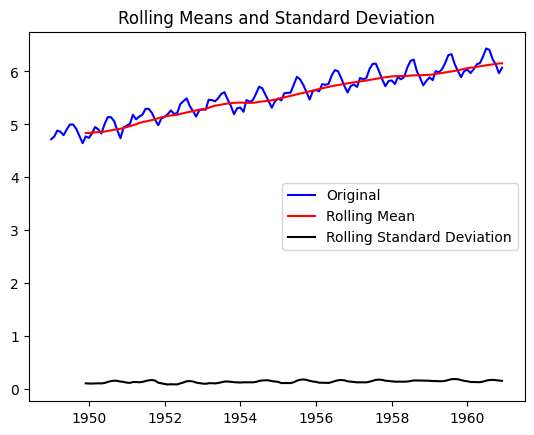

ADF Statistical Number -1.7170170891069607
P-Value 0.42236677477039125
Used Lags 13
No of Observation 130
Critical Values {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC -445.3990312497209


In [28]:
# Convert Time Seris in Logarithmic Time Series Values 
log_ts = np.log(ts)

# Log Time Seriest Top Values
print('Log Time Seriest Top Values :\n', log_ts.head())

# Stationary Test on Log Time Series Data
test_stationary(log_ts)

##### Time Series is Not Stationary
###### P-Value : 0.422 Still Higer Then 0.05

####  Double Log Transformation

Double Log Time Seriest Top Values :
 Month
1949-01-01    1.551491
1949-02-01    1.562490
1949-03-01    1.585719
1949-04-01    1.581000
1949-05-01    1.567739
Name: #Passengers, dtype: float64


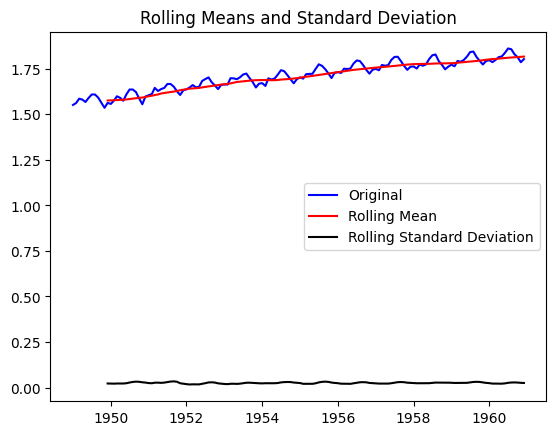

ADF Statistical Number -2.156027907005565
P-Value 0.22258989117061473
Used Lags 13
No of Observation 130
Critical Values {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC -879.8116466202985


In [29]:
# Convert Log Time Seris in Double Logarithmic Time Series Values 
double_log_ts = np.log(log_ts)

# Double Log Time Seriest Top Values
print('Double Log Time Seriest Top Values :\n', double_log_ts.head())

# Stationary Test on Double Log Time Series Data
test_stationary(double_log_ts)

##### Time Series is Not Stationary
##### P-Value : 0.2225 Still Higer Then 0.05

#### Log + MovingAverage + Diffrenceing

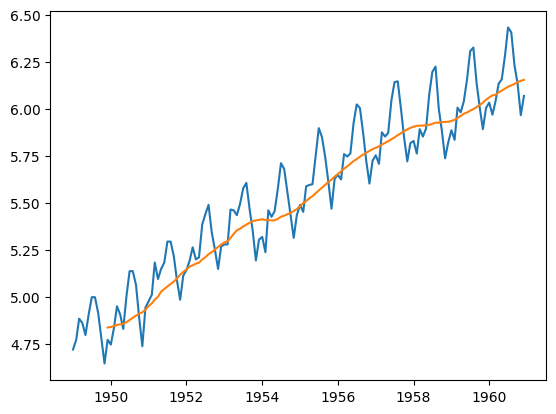

Month
1949-12-01   -0.065494
1950-01-01   -0.093449
1950-02-01   -0.007566
1950-03-01    0.099416
1950-04-01    0.052142
Name: #Passengers, dtype: float64


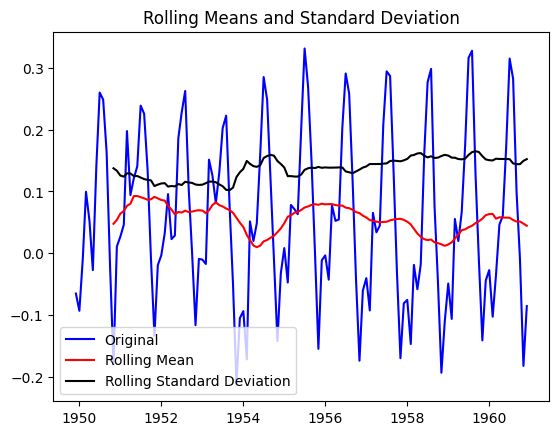

ADF Statistical Number -3.162907991300869
P-Value 0.022234630001243157
Used Lags 13
No of Observation 119
Critical Values {'1%': -3.4865346059036564, '5%': -2.8861509858476264, '10%': -2.579896092790057}
AIC -436.63269481747034


In [30]:
# Calculate Moving Average
moving_average = pd.Series(log_ts).rolling(window=12).mean()
plt.plot(log_ts)
plt.plot(moving_average)
plt.show()

# Diffrence Of Time Series by Moving Average
TS_Log_Moving_Avg_Diff = log_ts - moving_average
TS_Log_Moving_Avg_Diff.dropna(inplace=True)
print(TS_Log_Moving_Avg_Diff.head())

# Stationary Test on TS_Log_Moving_Avg_Diff Time Series Data
test_stationary(TS_Log_Moving_Avg_Diff)

###### Yes This Is Stationary
##### P-Value : 0.02225 Still Lower Then 0.05

### ExponentialMovingAvarage + Diffrencing

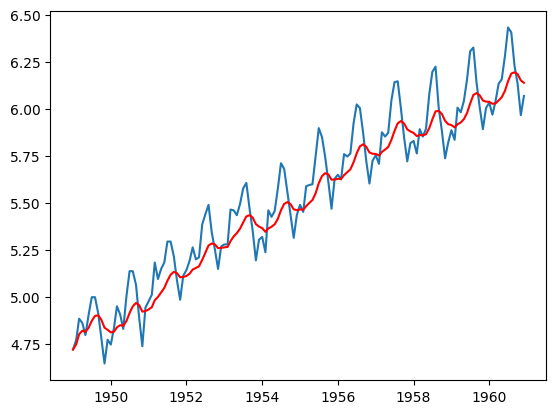

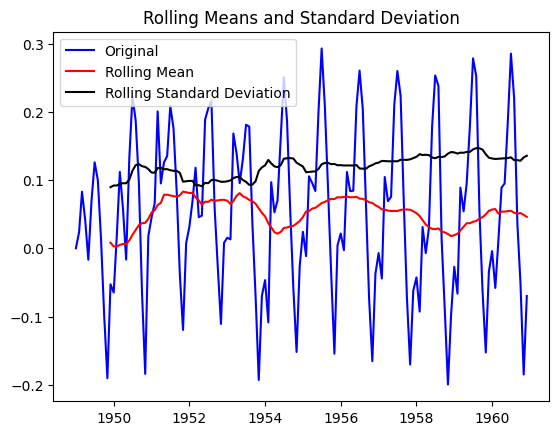

ADF Statistical Number -3.3105424543208746
P-Value 0.01441375329697869
Used Lags 13
No of Observation 130
Critical Values {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC -486.11770579662254


In [31]:
exp_wei_avg = log_ts.ewm(span=12).mean()
plt.plot(log_ts)
plt.plot(exp_wei_avg, color='red')
plt.show()

# time series - exp_mov_avg 
log_ts_ewma_diff = log_ts - exp_wei_avg
test_stationary(log_ts_ewma_diff)

###### P-Value : 0.014 P value Smaller Then 0.05
###### Data is Stationary

### Log Diffrencing

In [32]:
# Inverse Transform on Transform Time Series
ts = data['#Passengers']

# Turn Time Series in Logarithmic Time Series
log_ts = np.log(ts)

# Inverse Logarithmic by Exponential
ts_orig = np.exp(log_ts)

# Turn Log Values in Double Log
double_log_ts = np.log(log_ts)

# Inverse Doble Logarithmic By Twice Exponential
ts_orig1 = np.exp(double_log_ts)
ts_orig = np.log(ts_orig1)

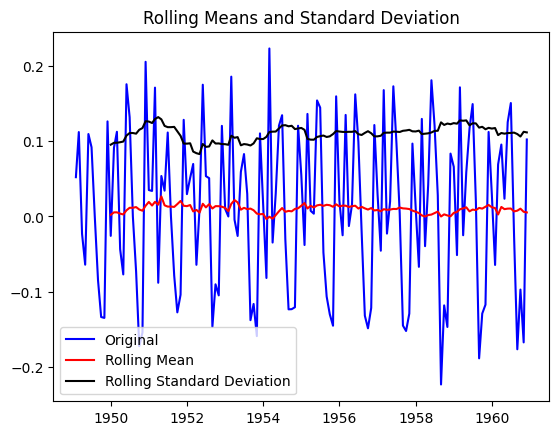

ADF Statistical Number -2.717130598388133
P-Value 0.07112054815085875
Used Lags 14
No of Observation 128
Critical Values {'1%': -3.4825006939887997, '5%': -2.884397984161377, '10%': -2.578960197753906}
AIC -440.35846985568105


In [33]:
# Log Diffrence Between Two Consecutive log Values
log_ts_diff = log_ts - log_ts.shift()

# Inverse Transformation of Log Diffrence
# Add shifted lag Values to the First log value to Get The Cumulative Sum
log_ts_cum_sum = log_ts_diff.cumsum()

# Add The Cumulative Sum To The First Log Values to Get Restored Log Time Series
log_ts_restored = log_ts.iloc[0] + log_ts_cum_sum

# Take The Exponential Of Restored Log 
ts_orig = np.exp(log_ts_restored)

# Test Stationary
test_stationary(log_ts_diff.dropna())

###### Not Stationay
###### Because P Values : 0.07112 That's Greater Then 0.05

## 3

### Seasonal Decomposition

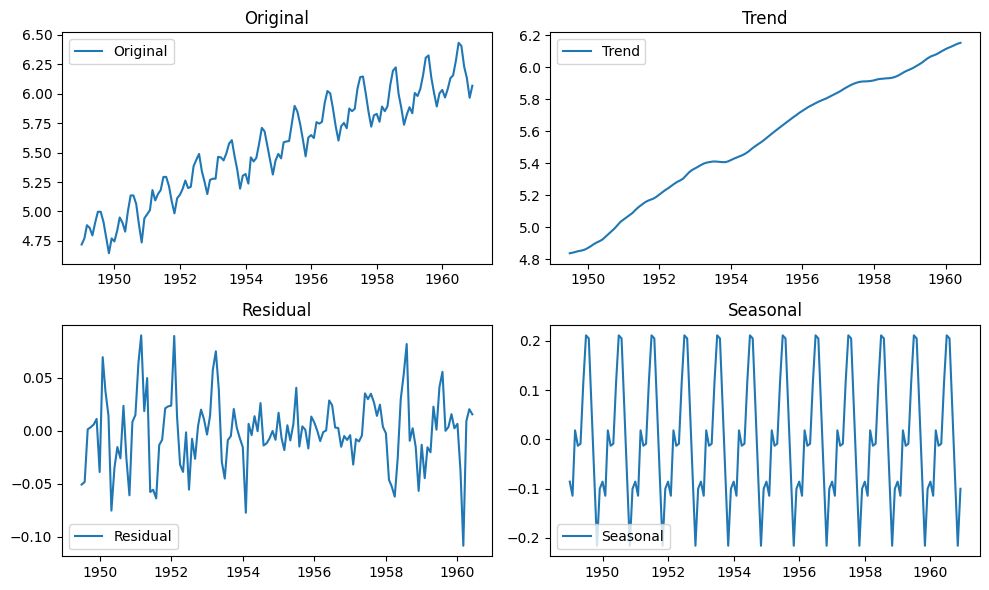

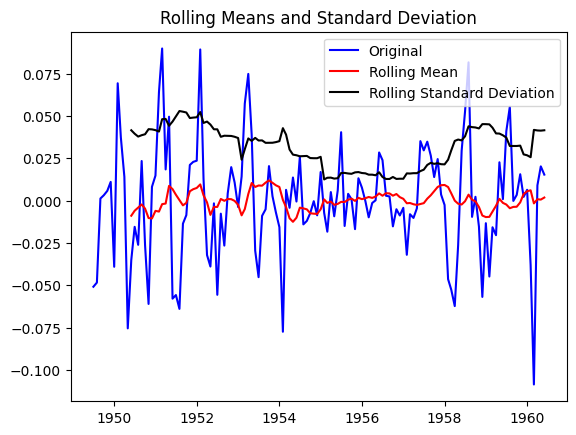

ADF Statistical Number -6.33238679764488
P-Value 2.8850589033231607e-08
Used Lags 9
No of Observation 122
Critical Values {'1%': -3.4851223522012855, '5%': -2.88553750045158, '10%': -2.5795685622144586}
AIC -517.2642969403794


In [34]:
# Decomposition
decomposition = sd(log_ts)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Create subplots properly
fig, axes = plt.subplots(2, 2, figsize=(10, 6)) # Subplot 2=Row, 2=Columnbs,  figsize(Width, Height)

# Original
axes[0, 0].plot(log_ts)
axes[0, 0].set_title('Original')
axes[0, 0].legend(['Original'], loc='best')

# Trend
axes[0, 1].plot(trend)
axes[0, 1].set_title('Trend')
axes[0, 1].legend(['Trend'], loc='best')

# Seasonal
axes[1, 1].plot(seasonal)
axes[1, 1].set_title('Seasonal')
axes[1, 1].legend(['Seasonal'], loc='best')

# Residual
axes[1, 0].plot(residual)
axes[1, 0].set_title('Residual')
axes[1, 0].legend(['Residual'], loc='best')

plt.tight_layout()
plt.show()

# Stationarity Test
ts_log_decompose = residual.dropna()
test_stationary(ts_log_decompose)


### Grid Search

In [35]:
# Define p, q, d
p_value = [1, 2]
d_value = [0, 1]
q_value = [1, 2]

best_rmse, best_p, best_d, best_q = np.inf, None, None, None
history = [x for x in train]

# Make Prediction
prediction = list()

# Perfrom grid Search
for p in p_value:
    for d in d_value:
        for q in q_value:
            order = {p, q, d}
            try:
                for t in (len(test)): 

SyntaxError: incomplete input (768303099.py, line 18)

### ARIMA Model Building

##### Train Test Split

In [36]:
ts_value = log_ts.values

x = ts_value
size = int(len(x) * 0.667)
train, test = x[0:size], x[size:len(x)]

print(f'Length and Percentage of Training Data :{len(train), round(len(train)/len(x)*100)}')
print(f'Length and Percentage of Testing Data :\t{len(test), round(len(test)/len(x)*100)}')

Length and Percentage of Training Data :(96, 67)
Length and Percentage of Testing Data :	(48, 33)


In [37]:
history = [x for x in train]
predictions = list()

for t in range(len(test)):
    try:
        model = ARIMA(history, order=(4, 1, 2)) # Order (p, d, q) by Grid Search 
        model_fit = model.fit()
        output = model_fit.forecast()
        yhat = output[0]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
    except(ValueError, LinAlgError):
        pass
    print('Pridicted :', yhat, 'unexpected :', obs)

error = mse(test, predictions)
rmse = mse(test, predictions)**0.5
print('Test MSE : %3.f', rmse)


Pridicted : 5.773418111859464 unexpected : 5.752572638825633
Pridicted : 5.7227148300704505 unexpected : 5.707110264748875
Pridicted : 5.731419960049943 unexpected : 5.87493073085203
Pridicted : 5.884513010292575 unexpected : 5.8522024797744745
Pridicted : 5.771684271639998 unexpected : 5.872117789475416
Pridicted : 5.924874080599787 unexpected : 6.045005314036012
Pridicted : 6.023705205410219 unexpected : 6.142037405587356
Pridicted : 6.163743266104592 unexpected : 6.1463292576688975
Pridicted : 6.173356439351637 unexpected : 6.0014148779611505
Pridicted : 5.897037205554104 unexpected : 5.849324779946859
Pridicted : 5.802940854670925 unexpected : 5.720311776607412
Pridicted : 5.774895346198028 unexpected : 5.817111159963204
Pridicted : 5.858828727628783 unexpected : 5.8289456176102075
Pridicted : 5.792581574458411 unexpected : 5.762051382780177
Pridicted : 5.785875623964186 unexpected : 5.8916442118257715
Pridicted : 5.919774605934723 unexpected : 5.8522024797744745
Pridicted : 5.8073

##### Visulize Prediction

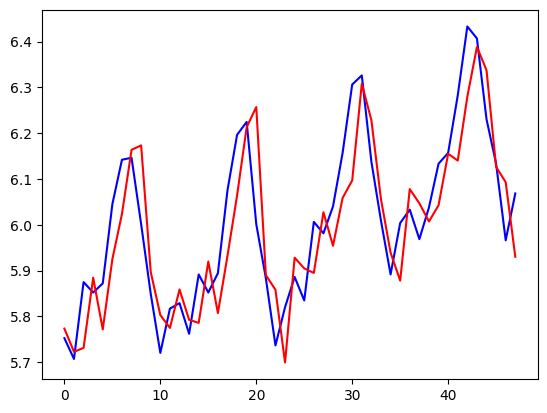

In [38]:
plt.plot(test, color='blue', label='test')
plt.plot(predictions, color='red', label='Pred')
plt.show()

##### Plot Exponential Raw Data Graph

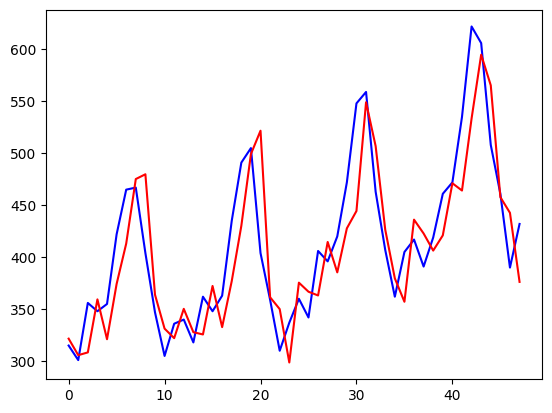

In [39]:
plt.plot(np.exp(test), color='blue', label='test')
plt.plot(np.exp(predictions), color='red', label='Pred')
plt.show()

### FaceBook Prophet

###### Data

In [2]:
data = pd.read_csv(r"E:\DATA FOR TEST\AirPassengers.csv")
df = data.copy()
df['Month'] = pd.to_datetime(df['Month'])

###### Pre_requeset for Rename Data to find y and time series as ds

In [3]:
df = df.rename(columns={
    '#Passengers' : 'y',
    'Month' : 'ds'
})

###### Save Copy of y

In [4]:
df['y_orig'] = df['y']

# Convert Data In Logarithmic Approach
df['y'] = np.log(df['y'])

df.head()


,ds,y,y_orig
0,1949-01-01,4.718499,112
1,1949-02-01,4.770685,118
2,1949-03-01,4.882802,132
3,1949-04-01,4.859812,129
4,1949-05-01,4.795791,121


##### FaceBook  Prophet Model Initilization

In [5]:
model = Prophet()
model.fit(df)

# Future Data 
FutureData = model.make_future_dataframe(periods=12, freq='M')

# Forcast Data
ForcastData = model.predict(FutureData)

# Top 5 Values
ForcastData.head(20)

17:56:05 - cmdstanpy - INFO - Chain [1] start processing
17:56:05 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,4.802626,4.666497,4.760673,4.802626,4.802626,-0.088786,-0.088786,-0.088786,-0.088786,-0.088786,-0.088786,0.0,0.0,0.0,4.713840
1,1949-02-01,4.808193,4.663051,4.756818,4.808193,4.808193,-0.100080,-0.100080,-0.100080,-0.100080,-0.100080,-0.100080,0.0,0.0,0.0,4.708113
2,1949-03-01,4.813220,4.790111,4.879143,4.813220,4.813220,0.021981,0.021981,0.021981,0.021981,0.021981,0.021981,0.0,0.0,0.0,4.835202
3,1949-04-01,4.818787,4.769509,4.860910,4.818787,4.818787,-0.002274,-0.002274,-0.002274,-0.002274,-0.002274,-0.002274,0.0,0.0,0.0,4.816512
4,1949-05-01,4.824174,4.768848,4.860242,4.824174,4.824174,-0.008738,-0.008738,-0.008738,-0.008738,-0.008738,-0.008738,0.0,0.0,0.0,4.815436
5,1949-06-01,4.829740,4.905774,4.996567,4.829740,4.829740,0.119075,0.119075,0.119075,0.119075,0.119075,0.119075,0.0,0.0,0.0,4.948815
6,1949-07-01,4.835129,5.006664,5.101265,4.835129,4.835129,0.216734,0.216734,0.216734,0.216734,0.216734,0.216734,0.0,0.0,0.0,5.051862
7,1949-08-01,4.840697,5.006353,5.097397,4.840697,4.840697,0.210153,0.210153,0.210153,0.210153,0.210153,0.210153,0.0,0.0,0.0,5.050850
8,1949-09-01,4.846265,4.861781,4.954931,4.846265,4.846265,0.063445,0.063445,0.063445,0.063445,0.063445,0.063445,0.0,0.0,0.0,4.909709
9,1949-10-01,4.851653,4.732971,4.823995,4.851653,4.851653,-0.070410,-0.070410,-0.070410,-0.070410,-0.070410,-0.070410,0.0,0.0,0.0,4.781243


In [6]:
# Top 5 Values of Forcast Data Index, yhat, yhat upper and yhat lower 
ForcastData[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head() 

,ds,yhat,yhat_lower,yhat_upper
0,1949-01-01,4.713840,4.666497,4.760673
1,1949-02-01,4.708113,4.663051,4.756818
2,1949-03-01,4.835202,4.790111,4.879143
3,1949-04-01,4.816512,4.769509,4.860910
4,1949-05-01,4.815436,4.768848,4.860242


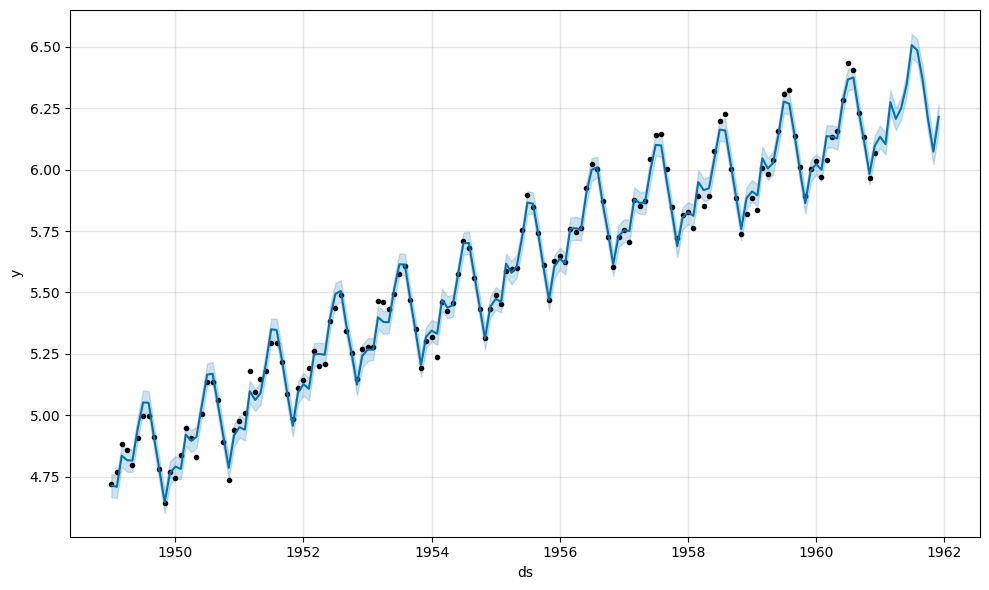

In [7]:
# Plot the model
model.plot(ForcastData);

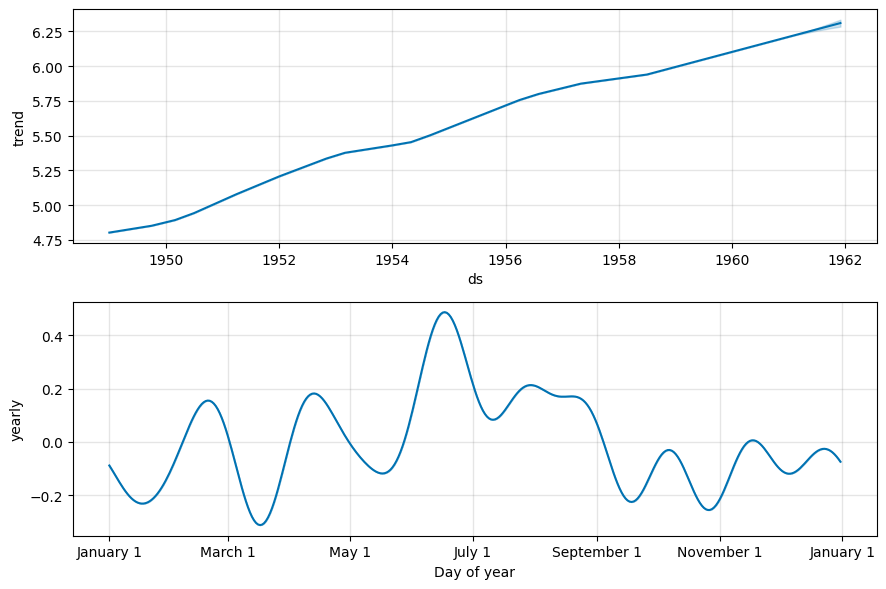

In [10]:
# Plot Component of Modle
model.plot_components(ForcastData);

In [9]:
ForcastData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ds                          156 non-null    datetime64[ns]
 1   trend                       156 non-null    float64       
 2   yhat_lower                  156 non-null    float64       
 3   yhat_upper                  156 non-null    float64       
 4   trend_lower                 156 non-null    float64       
 5   trend_upper                 156 non-null    float64       
 6   additive_terms              156 non-null    float64       
 7   additive_terms_lower        156 non-null    float64       
 8   additive_terms_upper        156 non-null    float64       
 9   yearly                      156 non-null    float64       
 10  yearly_lower                156 non-null    float64       
 11  yearly_upper                156 non-null    float64       